In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/cleaned_biogas.csv")

df.head()

,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),Chicken Litter (kg),Cassava (kg),Bagasse Feed (kg),Energy Grass (kg),Banana Shafts (kg),...,Fish Waste (kg),Water (L),Diesel (L),Electricity Use (kWh),Temperature (C),Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
0,2010,1,1,14.785537,7.305310,13.050192,17.684926,14.830197,9.906063,7.743000,...,4.191195,82.619547,2.866209,25.258583,33.135037,75.997637,10.193971,26.666653,36.841906,58.956420
1,2010,1,1,15.254357,16.039052,12.686489,10.436417,17.292921,16.466707,5.785339,...,5.903021,107.321735,3.588735,34.322305,29.268128,76.987494,1.284466,23.100934,32.535921,71.951004
2,2010,1,1,35.566142,19.992287,8.336992,33.463391,15.889184,5.330412,9.085270,...,4.300494,138.387090,0.070003,18.190760,31.736523,81.425018,3.108892,21.273712,37.357393,102.965090
3,2010,1,2,34.496363,17.751484,8.232446,14.096671,14.088245,8.093446,11.882885,...,7.469573,99.479363,1.532482,44.195734,29.677593,85.800528,1.940286,31.250011,33.820132,83.783745
4,2010,1,2,21.187255,13.533476,14.489672,14.756190,12.165611,12.064431,4.597625,...,2.617079,86.328262,0.362056,30.257209,29.731208,73.236587,2.442031,20.177435,36.571963,70.489410


In [3]:
df.columns

Index(['Year', 'Month', 'Day', 'Pig Manure (kg)', 'Kitchen Food Waste (kg)',
       'Chicken Litter (kg)', 'Cassava (kg)', 'Bagasse Feed (kg)',
       'Energy Grass (kg)', 'Banana Shafts (kg)', 'Alcohol Waste (kg)',
       'Municipal Residue (kg)', 'Fish Waste (kg)', 'Water (L)', 'Diesel (L)',
       'Electricity Use (kWh)', 'Temperature (C)', 'Humidity (%)',
       'Rainfall (mm)', 'C/N Ratio', 'Digester Temp (C)', 'biogas_production'],
      dtype='object')

In [4]:
X = df.drop(columns=["biogas_production"])

y = df["biogas_production"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6054149042005557
RMSE: 0.8422183186594604
R2 Score: 0.9942703586603004


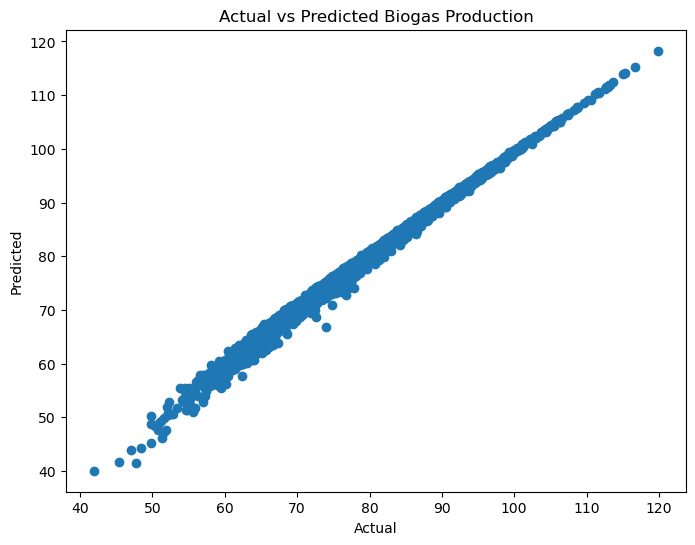

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Biogas Production")

plt.show()